<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/01_text_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Preprocessing

Natural Language Processing (NLP) enables computers to understand, process, and generate human language.

However, raw text often contains punctuation, uppercase letters, numbers, special characters, and common words that add little value for many NLP tasks.

Text preprocessing is the process of cleaning and standardizing text so it becomes easier for machine learning models to analyze.

Common preprocessing techniques include tokenization, lowercasing, removing punctuation, removing stop words, stemming, and lemmatization.

In [1]:
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [5]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [6]:
text = "Artificial Intelligence is transforming the world by enabling machines to understand human language."

print(text)

Artificial Intelligence is transforming the world by enabling machines to understand human language.


In [7]:
tokens = word_tokenize(text)

print(tokens)

['Artificial', 'Intelligence', 'is', 'transforming', 'the', 'world', 'by', 'enabling', 'machines', 'to', 'understand', 'human', 'language', '.']


In [8]:
lower_tokens = [word.lower() for word in tokens]

print(lower_tokens)

['artificial', 'intelligence', 'is', 'transforming', 'the', 'world', 'by', 'enabling', 'machines', 'to', 'understand', 'human', 'language', '.']


In [9]:
clean_tokens = [
    word for word in lower_tokens
    if word not in string.punctuation
]

print(clean_tokens)

['artificial', 'intelligence', 'is', 'transforming', 'the', 'world', 'by', 'enabling', 'machines', 'to', 'understand', 'human', 'language']


In [10]:
stop_words = set(stopwords.words("english"))

filtered_tokens = [
    word for word in clean_tokens
    if word not in stop_words
]

print(filtered_tokens)

['artificial', 'intelligence', 'transforming', 'world', 'enabling', 'machines', 'understand', 'human', 'language']


In [11]:
stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in filtered_tokens
]

print(stemmed_words)

['artifici', 'intellig', 'transform', 'world', 'enabl', 'machin', 'understand', 'human', 'languag']


In [12]:
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print(lemmatized_words)

['artificial', 'intelligence', 'transforming', 'world', 'enabling', 'machine', 'understand', 'human', 'language']


In [13]:
import pandas as pd

comparison = pd.DataFrame({

    "Original": filtered_tokens,
    "Stemmed": stemmed_words,
    "Lemmatized": lemmatized_words

})

comparison

,Original,Stemmed,Lemmatized
0,artificial,artifici,artificial
1,intelligence,intellig,intelligence
2,transforming,transform,transforming
3,world,world,world
4,enabling,enabl,enabling
5,machines,machin,machine
6,understand,understand,understand
7,human,human,human
8,language,languag,language


In [14]:
processed_text = " ".join(lemmatized_words)

print(processed_text)

artificial intelligence transforming world enabling machine understand human language


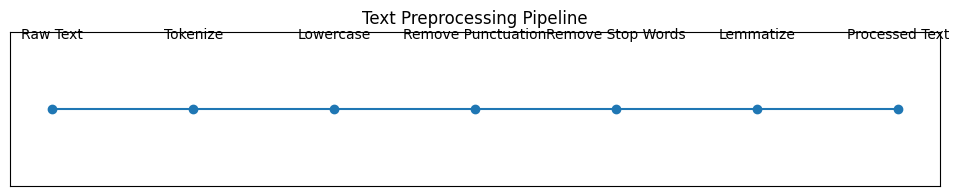

In [15]:
import matplotlib.pyplot as plt

steps = [
    "Raw Text",
    "Tokenize",
    "Lowercase",
    "Remove Punctuation",
    "Remove Stop Words",
    "Lemmatize",
    "Processed Text"
]

plt.figure(figsize=(12,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Text Preprocessing Pipeline")

plt.show()